In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [14]:
import arff

with open("../data/dataset.arff", "r") as f:
    dataset = arff.load(f)

df = pd.DataFrame(dataset["data"], columns=[attr[0] for attr in dataset["attributes"]])

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [15]:
# Copiar dataset para evitar modificar o original
data = df.copy()

# Renomear colunas para facilitar uso (remover espaços e caracteres especiais)
data.columns = [
    c.strip()
     .replace(" ", "_")
     .replace("[", "")
     .replace("]", "")
     .replace("/", "_")
    for c in data.columns
]

data.columns

Index(['UDI', 'Product_ID', 'Type', 'Air_temperature_K',
       'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm',
       'Tool_wear_min', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='str')

In [16]:
# Definir coluna alvo
target = "Machine_failure"

# Remover colunas que causam vazamento de informação + IDs irrelevantes
drop_cols = [
    "UDI",
    "Product_ID",
    "TWF", "HDF", "PWF", "OSF", "RNF"
]

X = data.drop(columns=drop_cols + [target])
y = data[target].astype(int)

X.head(), y.value_counts()

(  Type  Air_temperature_K  Process_temperature_K  Rotational_speed_rpm  \
 0    M              298.1                  308.6                  1551   
 1    L              298.2                  308.7                  1408   
 2    L              298.1                  308.5                  1498   
 3    L              298.2                  308.6                  1433   
 4    L              298.2                  308.7                  1408   
 
    Torque_Nm  Tool_wear_min  
 0       42.8              0  
 1       46.3              3  
 2       49.4              5  
 3       39.5              7  
 4       40.0              9  ,
 Machine_failure
 0    9661
 1     339
 Name: count, dtype: int64)

In [17]:
# Distribuição da variável alvo (%)
(y.value_counts(normalize=True) * 100).round(2)

Machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [18]:
# Estatísticas básicas
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Air_temperature_K,10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process_temperature_K,10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational_speed_rpm,10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque_Nm,10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool_wear_min,10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


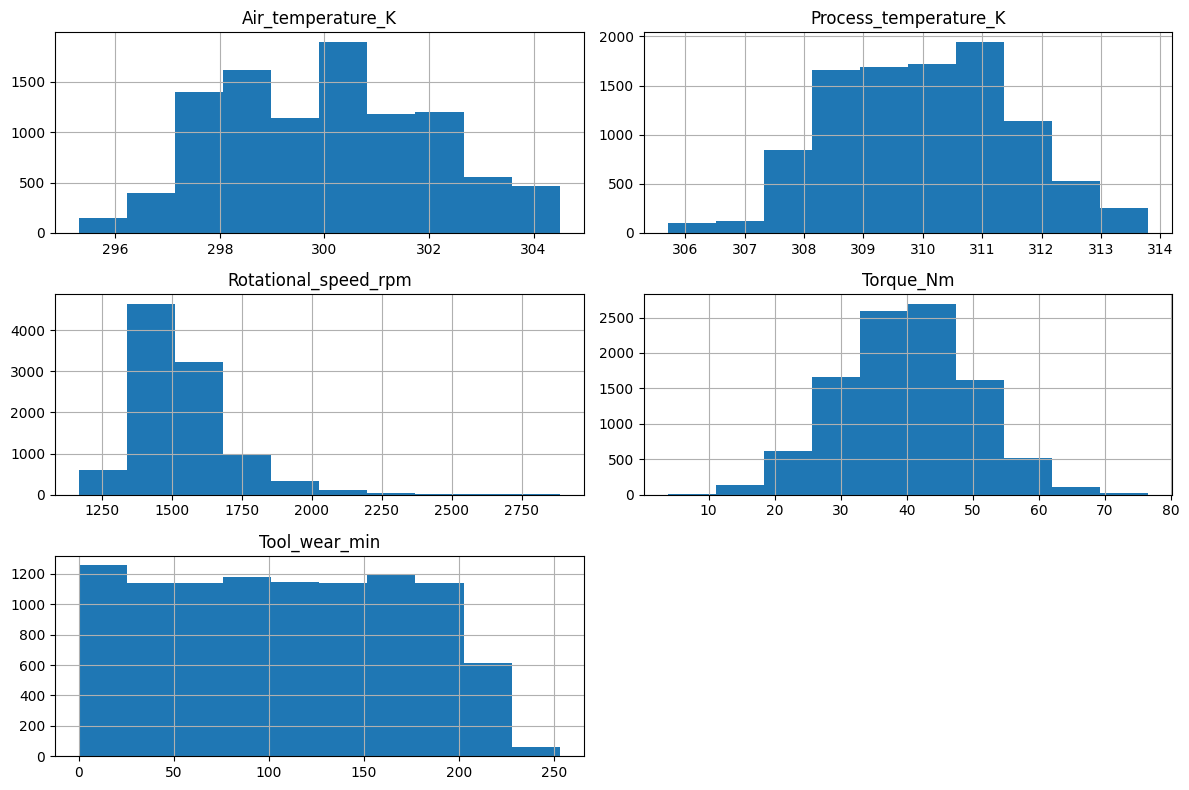

In [19]:
# Histogramas das variáveis numéricas
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

X[num_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

# Split treino/teste com estratificação (muito importante em dataset desbalanceado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Separar colunas categóricas e numéricas
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Pré-processamento
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

# Modelo
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

# Pipeline completo
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

# Treinar
clf.fit(X_train, y_train)

# Prever
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

/tmp/ipykernel_8241/2590248457.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


              precision    recall  f1-score   support

           0     0.9812    0.9984    0.9897      1932
           1     0.9118    0.4559    0.6078        68

    accuracy                         0.9800      2000
   macro avg     0.9465    0.7272    0.7988      2000
weighted avg     0.9788    0.9800    0.9768      2000



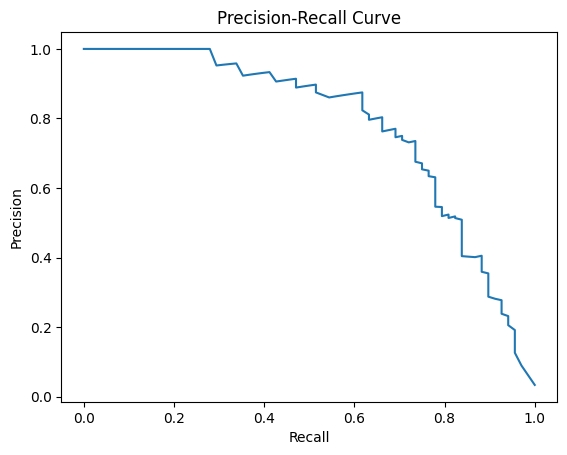

In [21]:
from sklearn.metrics import precision_recall_curve

# Probabilidades
y_proba = clf.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [22]:
# Ajustar threshold
threshold = 0.3  # teste 0.3

y_pred_adjusted = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_adjusted, digits=4))

              precision    recall  f1-score   support

           0     0.9887    0.9928    0.9907      1932
           1     0.7667    0.6765    0.7188        68

    accuracy                         0.9820      2000
   macro avg     0.8777    0.8346    0.8547      2000
weighted avg     0.9811    0.9820    0.9815      2000



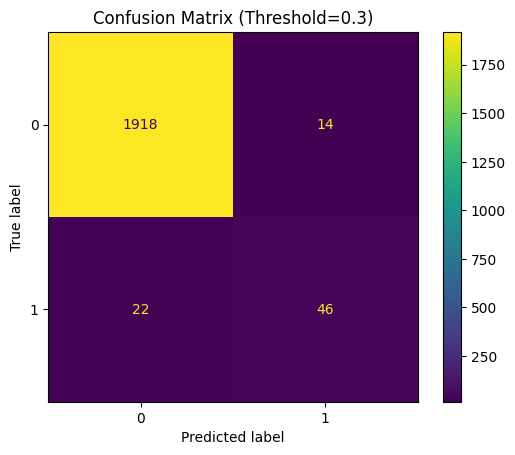

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_adjusted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Threshold=0.3)")
plt.show()

In [24]:
# Get feature names after preprocessing
ohe = clf.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = []

if len(cat_cols) > 0:
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()

feature_names = num_cols + cat_feature_names

importances = clf.named_steps["model"].feature_importances_

fi = pd.DataFrame({"feature": feature_names, "importance": importances})
fi = fi.sort_values("importance", ascending=False).head(10)
fi

,feature,importance
2,Rotational_speed_rpm,0.302162
3,Torque_Nm,0.300237
4,Tool_wear_min,0.199520
0,Air_temperature_K,0.103964
1,Process_temperature_K,0.074626
6,Type_L,0.009457
7,Type_M,0.006314
5,Type_H,0.003720


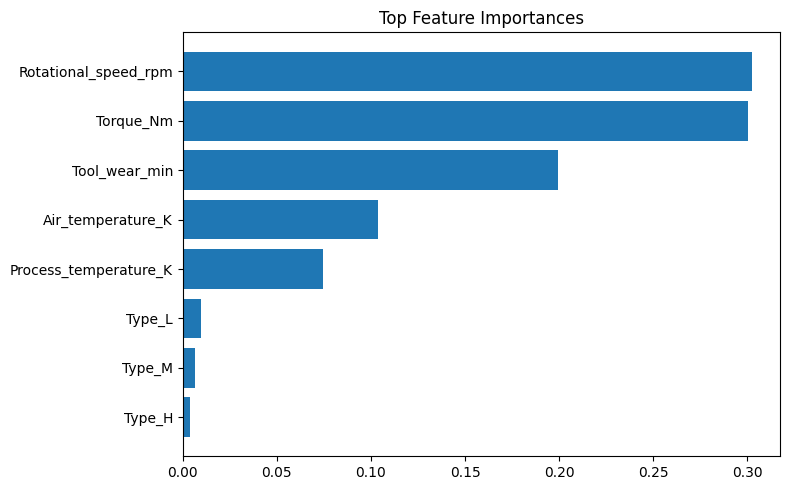

In [25]:
plt.figure(figsize=(8,5))
plt.barh(fi["feature"][::-1], fi["importance"][::-1])
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()

## Conclusions

- Built an end-to-end predictive maintenance pipeline using pandas, scikit-learn and threshold tuning.
- Improved the recall of the failure class from **0.45 → 0.67** by adjusting the decision threshold.
- Identified top influential features (e.g. torque, rotational speed, temperature differences).
- Designed a workflow aligned with production AI use-cases (Fraunhofer IPT focus).

## Next Steps
- Time-aware validation and drift monitoring.
- FastAPI inference endpoint.
- Hyperparameter tuning.
- Deployment using Docker.